In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-default' dataset.
Path to dataset files: /kaggle/input/loan-default


In [3]:
import os
os.listdir(path)

['Loan_default.csv']

In [6]:
df = pd.read_csv(path+"/Loan_default.csv")

In [8]:
print(df.shape)

(255347, 18)


In [9]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [12]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [13]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [15]:
df.describe(include = 'object')

,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347,255347
unique,255347,4,4,3,2,2,5,2
top,ZTH91CGL0B,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,1,64366,64161,85302,127677,127742,51298,127701


In [17]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [21]:
df.drop(columns = ['LoanID'], inplace = True)

In [22]:
print(df.shape)

(255347, 17)


In [23]:
df['Default'].value_counts()

,count
Default,
0,225694
1,29653


In [25]:
df['Default'].value_counts(normalize = True)*100

,proportion
Default,
0,88.387175
1,11.612825


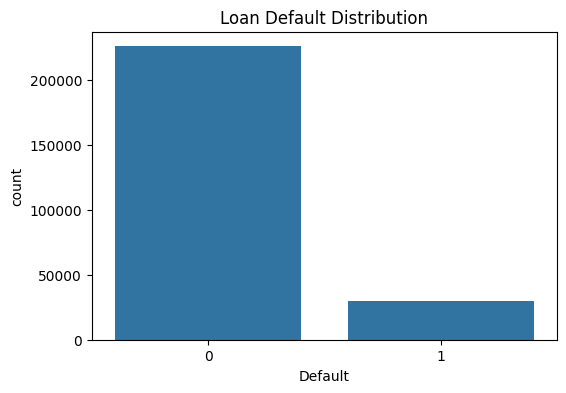

In [27]:
plt.figure(figsize = (6, 4))
sns.countplot(x = "Default", data = df)
plt.title("Loan Default Distribution")
plt.show()

In [28]:
print(df.select_dtypes(include='object').columns.tolist())

['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [30]:
df_encoded = df.copy()

le = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include='object').columns

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


In [31]:
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  int64  
 10  EmploymentType  255347 non-null  int64  
 11  MaritalStatus   255347 non-null  int64  
 12  HasMortgage     255347 non-null  int64  
 13  HasDependents   255347 non-null  int64  
 14  LoanPurpose     255347 non-null  int64  
 15  HasCoSigner     255347 non-null  int64  
 16  Default         255347 non-null  int64  
dtypes: float64

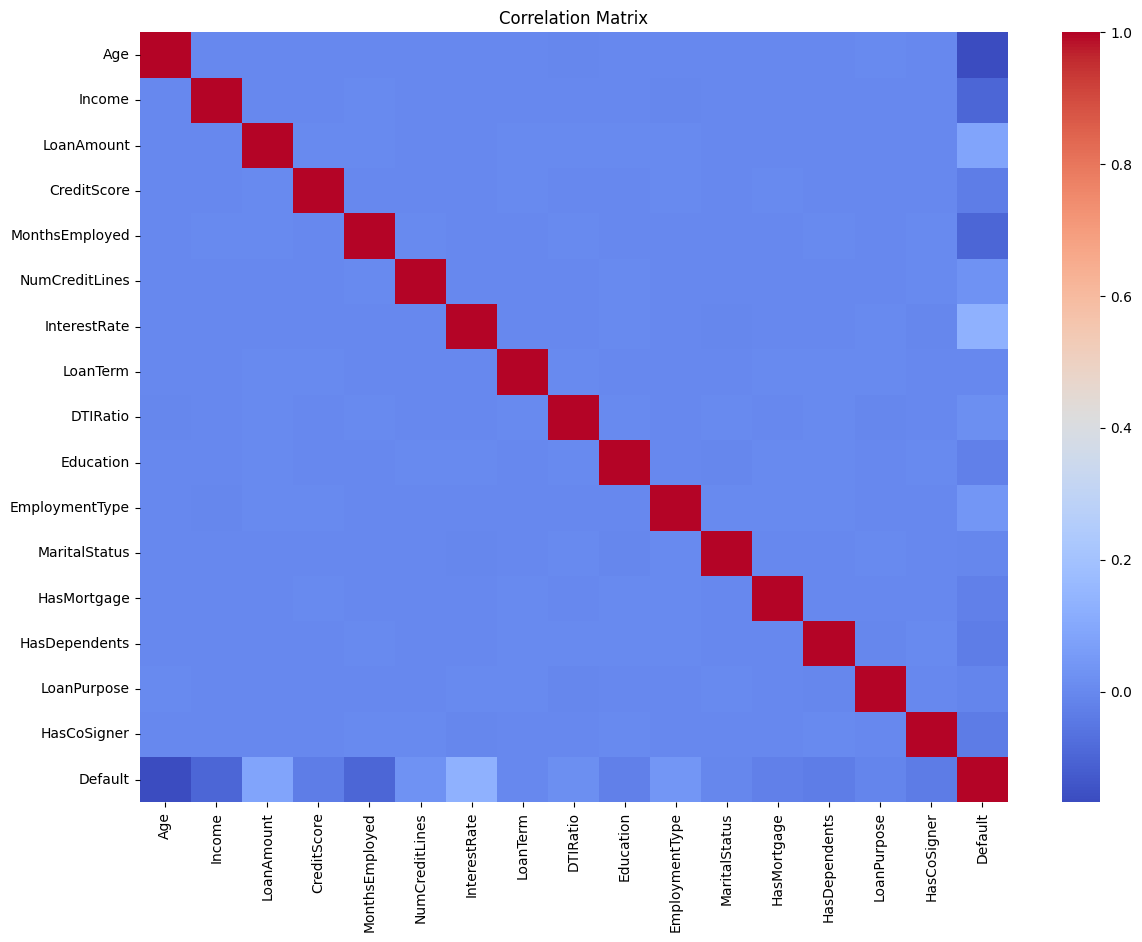

In [36]:
plt.figure(figsize=(14,10))

sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot = False)

plt.title("Correlation Matrix")
plt.show()

In [37]:
corr_target = df_encoded.corr()['Default'].sort_values(ascending=False)

print(corr_target)

Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
EmploymentType    0.041010
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
MaritalStatus    -0.007902
LoanPurpose      -0.010096
Education        -0.022835
HasMortgage      -0.022856
CreditScore      -0.034166
HasDependents    -0.034678
HasCoSigner      -0.039109
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64


In [38]:
X = df_encoded.drop("Default", axis=1)
y = df_encoded["Default"]

print(X.shape)
print(y.shape)

(255347, 16)
(255347,)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(204277, 16)
(51070, 16)


In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(204277, 16)


**Logistic Regression**

In [41]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [42]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy:
0.673996475425886

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.67     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.67      0.73     51070


Confusion Matrix:
[[30251 14888]
 [ 1761  4170]]


**Random Forest**

In [43]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [44]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy:
0.8852359506559624

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.65      0.03      0.05      5931

    accuracy                           0.89     51070
   macro avg       0.77      0.51      0.49     51070
weighted avg       0.86      0.89      0.84     51070


Confusion Matrix:
[[45056    83]
 [ 5778   153]]


In [45]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
6     InterestRate    0.134506
0              Age    0.128466
1           Income    0.126823
2       LoanAmount    0.113858
4   MonthsEmployed    0.102479
3      CreditScore    0.095474
8         DTIRatio    0.084569
7         LoanTerm    0.035213
14     LoanPurpose    0.034659
5   NumCreditLines    0.029103
9        Education    0.028902
10  EmploymentType    0.028020
11   MaritalStatus    0.022415
12     HasMortgage    0.012915
13   HasDependents    0.011662
15     HasCoSigner    0.010935


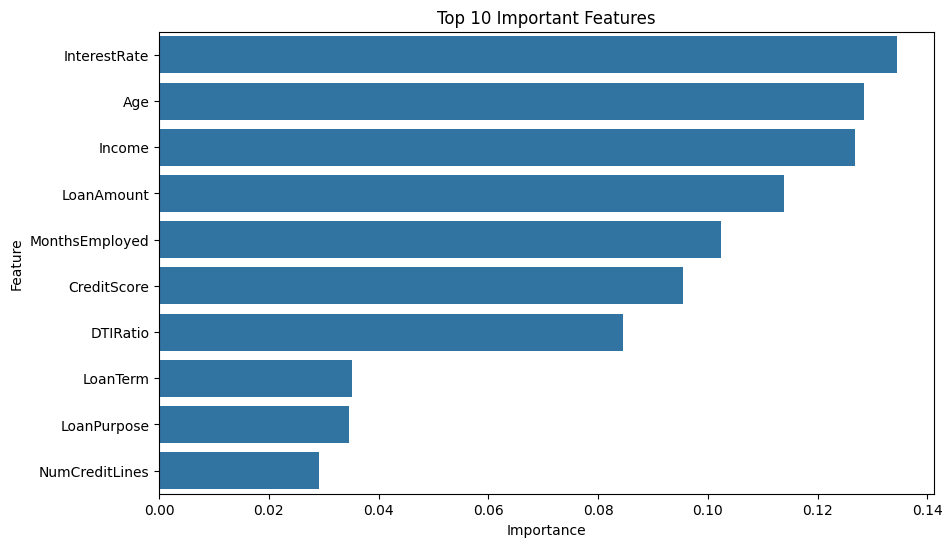

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

**Fix Random Forest Using SMOTE**

In [47]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(361110, 16)
Default
0    180555
1    180555
Name: count, dtype: int64


In [48]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf_smote = rf_smote.predict(X_test)

In [49]:
print(accuracy_score(y_test, y_pred_rf_smote))

print(classification_report(y_test, y_pred_rf_smote))

print(confusion_matrix(y_test, y_pred_rf_smote))

0.8283336596827884
              precision    recall  f1-score   support

           0       0.90      0.91      0.90     45139
           1       0.25      0.23      0.24      5931

    accuracy                           0.83     51070
   macro avg       0.57      0.57      0.57     51070
weighted avg       0.82      0.83      0.83     51070

[[40925  4214]
 [ 4553  1378]]


**K Means**

In [50]:
seg_features = df_encoded[
    ["Income", "CreditScore", "LoanAmount", "DTIRatio", "Age"]
]

In [51]:
scaler_seg = StandardScaler()

seg_scaled = scaler_seg.fit_transform(seg_features)

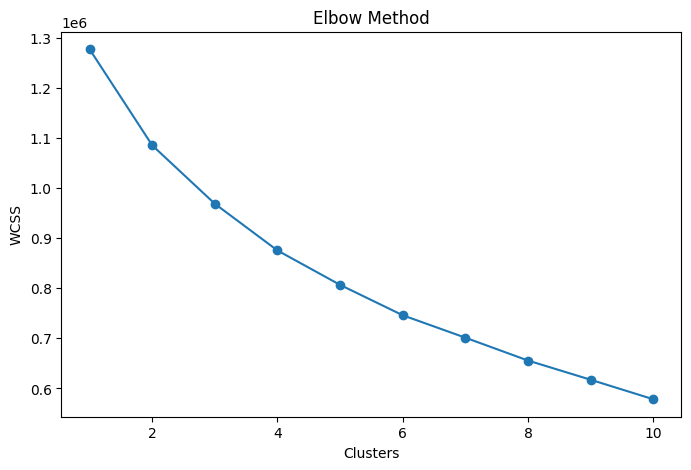

In [52]:
wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(seg_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [53]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_encoded["Cluster"] = kmeans.fit_predict(seg_scaled)

print(df_encoded["Cluster"].value_counts())

Cluster
0    95819
2    79988
1    79540
Name: count, dtype: int64


In [54]:
cluster_summary = df_encoded.groupby("Cluster")[
    [
        "Income",
        "CreditScore",
        "LoanAmount",
        "Age",
        "DTIRatio"
    ]
].mean()

print(cluster_summary)

                Income  CreditScore     LoanAmount        Age  DTIRatio
Cluster                                                                
0         83107.844165   741.555600  127497.384454  43.380478  0.495121
1        118488.289615   471.321461  126583.217978  43.477056  0.501616
2         45982.908124   476.229597  128666.544144  43.660587  0.504915


In [55]:
cluster_labels = {
    0: "Premium Customer",
    1: "High Income Risk",
    2: "High Risk Customer"
}

df_encoded["CustomerSegment"] = (
    df_encoded["Cluster"]
    .map(cluster_labels)
)

print(df_encoded[
    ["Cluster","CustomerSegment"]
].head())

   Cluster     CustomerSegment
0        1    High Income Risk
1        2  High Risk Customer
2        1    High Income Risk
3        0    Premium Customer
4        2  High Risk Customer


**PCA**

In [56]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(seg_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

print("Total Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.20115021 0.20047919]
Total Variance: 0.40162939553597654


In [57]:
pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = df_encoded["Cluster"]

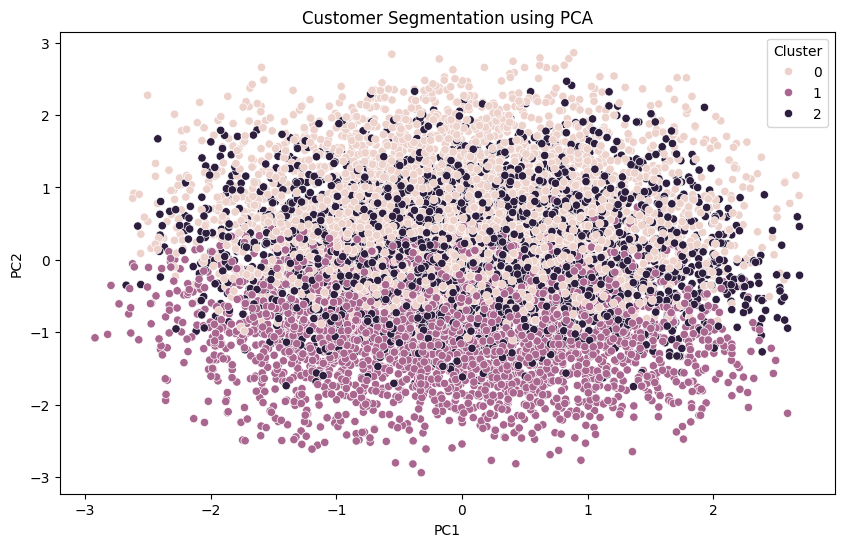

In [58]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df.sample(10000),
    x="PC1",
    y="PC2",
    hue="Cluster"
)

plt.title("Customer Segmentation using PCA")
plt.show()

The graph shows:

- Cluster 0 (Premium Customers) concentrated mostly in the upper region.
- Cluster 1 (High Income Risk) concentrated mostly in the lower region.
- Cluster 2 (High Risk Customers) distributed around the center.

This indicates K-Means successfully separated customers based on financial behavior.

In [60]:
import joblib

joblib.dump(lr, "loan_approval_model.pkl")
joblib.dump(kmeans, "customer_segmentation_model.pkl")

joblib.dump(scaler, "loan_scaler.pkl")
joblib.dump(scaler_seg, "segmentation_scaler.pkl")
joblib.dump(pca, "pca_model.pkl")

['risk_prediction_model.pkl']

In [61]:
import os

size = os.path.getsize("risk_prediction_model.pkl")

print(f"{size/(1024*1024):.2f} MB")

1852.14 MB
